In [ ]:
# ### 1. Mount Google Drive ###

from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
### 2. Prepare data ###

!scp '/content/gdrive/MyDrive/Workshop Conference/Workshop/2025/AIMI 2025 workshop VNIT/Object Detection and Classification/datasets/Brain Tumor YOLO dataset.zip' '/content/data.zip'

!unzip '/content/data.zip' -d '/content/'

Archive:  /content/data.zip
 extracting: /content/README.dataset.txt  
 extracting: /content/README.roboflow.txt  
 extracting: /content/data.yaml      
   creating: /content/test/
   creating: /content/test/images/
 extracting: /content/test/images/y701_jpg.rf.81a4472f77fdc1f31537342ceca340c9.jpg  
 extracting: /content/test/images/y702_jpg.rf.bc09b4ae34c8da942f93ad0d60d6f05f.jpg  
 extracting: /content/test/images/y703_jpg.rf.2b6fdf1363f8dfa6dbfe7f72e8a23133.jpg  
 extracting: /content/test/images/y704_jpg.rf.fea190a70904afe21b7479aefa60e661.jpg  
 extracting: /content/test/images/y705_jpg.rf.254d261010e9cb81690397999575ce83.jpg  
 extracting: /content/test/images/y706_jpg.rf.93ece8603f087f1d105943420a5dd89f.jpg  
 extracting: /content/test/images/y707_jpg.rf.eda3de4a5db9174097c426944218c338.jpg  
 extracting: /content/test/images/y708_jpg.rf.e6d6f68dc83014b88ff022310d5e0223.jpg  
 extracting: /content/test/images/y709_jpg.rf.4abcd82db5678b76d44c8395096f2055.jpg  
 extracting: /conte

In [ ]:
### 3. Install packages ###

!git clone https://github.com/autogyro/yolo-V8.git
!cd yolo-V8/ && pip install ultralytics

Cloning into 'yolo-V8'...
remote: Enumerating objects: 2723, done.
remote: Total 2723 (delta 0), reused 0 (delta 0), pack-reused 2723 (from 1)
Receiving objects: 100% (2723/2723), 1.41 MiB | 27.76 MiB/s, done.
Resolving deltas: 100% (1855/1855), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.8/978.8 kB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
### 4. Train model ###

import os

from ultralytics import YOLO


config_path = '/content/data.yaml'


!yolo task=detect mode=train model=yolov8n.pt data={config_path} epochs=50 imgsz=640 plots=True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100% 6.25M/6.25M [00:00<00:00, 320MB/s]
Ultralytics 8.3.111 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou

In [ ]:
# ------------------ Fix for Encoding Issues ------------------
# Sometimes, especially on platforms like Google Colab or Windows,
# you might face locale/encoding issues when running external commands.
# So, you override 'getpreferredencoding' to always return 'UTF-8'.

import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"

# Patch the 'locale' module's getpreferredencoding method
locale.getpreferredencoding = getpreferredencoding

# ------------------ Run YOLOv8 Validation ------------------
# This command runs validation (evaluation) of a trained YOLO model.

!yolo task=detect mode=val model=runs/detect/train/weights/best.pt data=/content/data.yaml save_json=True

Ultralytics 8.3.111 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1548.4±837.0 MB/s, size: 78.6 KB)
val: Scanning /content/valid/labels.cache... 201 images, 74 backgrounds, 0 corrupt: 100% 201/201 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 13/13 [00:03<00:00,  4.12it/s]
                   all        201        128       0.73      0.844      0.745      0.625
Speed: 1.7ms preprocess, 4.6ms inference, 0.0ms loss, 2.3ms postprocess per image
Saving runs/detect/val/predictions.json...
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


Ultralytics 8.3.111 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 /content/test/images/y701_jpg.rf.81a4472f77fdc1f31537342ceca340c9.jpg: 640x640 1 Tumor, 9.5ms
Speed: 3.1ms preprocess, 9.5ms inference, 143.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


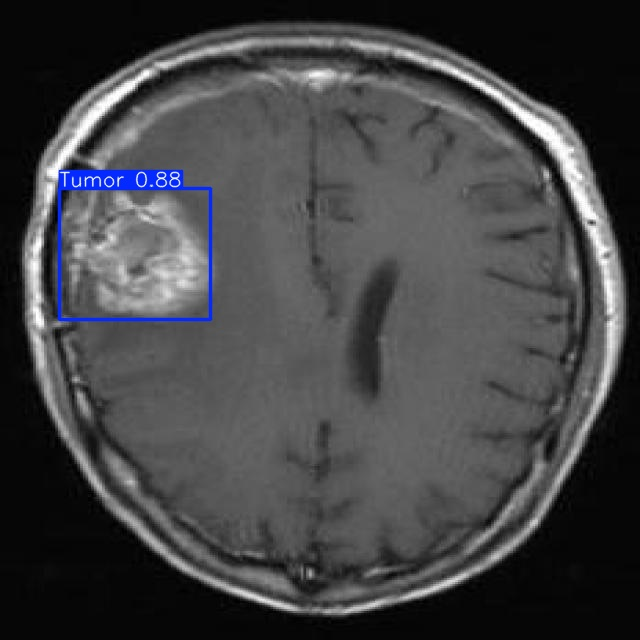

In [ ]:
from IPython.display import Image, display
import glob

!yolo predict model=/content/runs/detect/train/weights/best.pt \
              source=/content/test/images/y701_jpg.rf.81a4472f77fdc1f31537342ceca340c9.jpg \
              project=/content/runs/detect \
              name=predict \
              exist_ok=True


# Find the path of the predicted image (YOLOv8 saves output in 'runs/detect/predict' by default)
predicted_images = glob.glob('/content/runs/detect/predict/*.jpg')  # or .png if needed

# Display the first predicted image
if predicted_images:
    display(Image(filename=predicted_images[0]))
else:
    print("No predicted images found.")


In [ ]:
from ultralytics import YOLO
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Paths
test_folder = '/content/test/images'
output_folder = '/content/runs/detect'
output_name = 'predictions'
output_path = os.path.join(output_folder, output_name)

# Ensure output directory exists
os.makedirs(output_path, exist_ok=True)

# Load model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Select up to 16 test images
test_images = [os.path.join(test_folder, img) for img in os.listdir(test_folder) if img.endswith(('.jpg', '.png'))][:16]

# Run predictions and save
results = []
for img_path in test_images:
    result = model.predict(source=img_path, save=True, save_txt=True, project=output_folder, name=output_name, exist_ok=True)
    results.append(result)

# Gather predicted image paths
predicted_images = [os.path.join(output_path, os.path.basename(img_path)) for img_path in test_images]

# Display images in 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

for i, img_path in enumerate(predicted_images):
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        axes[i].imshow(img)
        axes[i].set_title(os.path.basename(img_path), fontsize=8)
        axes[i].axis('off')
    else:
        axes[i].axis('off')
        axes[i].set_title("Image not found", fontsize=8)

plt.tight_layout()
plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [ ]:
### 5. Download results ###

from google.colab import files


!zip -r /content/runs.zip /content/runs

files.download('/content/runs.zip')

  adding: content/runs/ (stored 0%)
  adding: content/runs/detect/ (stored 0%)
  adding: content/runs/detect/predict/ (stored 0%)
  adding: content/runs/detect/predict/predictions7/ (stored 0%)
  adding: content/runs/detect/predict/predictions7/y749_jpg.rf.dbdde7a94b211da9d20e76a0f94781f0.jpg (deflated 6%)
  adding: content/runs/detect/predict/predictions7/labels/ (stored 0%)
  adding: content/runs/detect/predict/predictions7/labels/y749_jpg.rf.dbdde7a94b211da9d20e76a0f94781f0.txt (deflated 8%)
  adding: content/runs/detect/predict/predictions14/ (stored 0%)
  adding: content/runs/detect/predict/predictions14/y772_jpg.rf.70d6887c1e69bc0d45540272e9fbb228.jpg (deflated 5%)
  adding: content/runs/detect/predict/predictions14/labels/ (stored 0%)
  adding: content/runs/detect/predict/predictions14/labels/y772_jpg.rf.70d6887c1e69bc0d45540272e9fbb228.txt (deflated 16%)
  adding: content/runs/detect/predict/predictions4/ (stored 0%)
  adding: content/runs/detect/predict/predictions4/y704_jpg.r

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>